# Traffic-signal-control experiment

This notebook compares simple baselines, MAPPO, and reward-sharing MAPPO on a network.

In [1]:
import os
import subprocess
import sys
import sysconfig
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content/marl-tsc")

    if not ROOT.exists():
        subprocess.run([
            "git", "clone", "--branch", "zak-pre-experiment",
            "--single-branch", "https://github.com/abergh18/marl-tsc.git",
            str(ROOT)
        ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "eclipse-sumo"
    ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "-r", str(ROOT / "requirements.txt"),
    ], check=True)

    import sumo
    os.environ["SUMO_HOME"] = sumo.SUMO_HOME
    sys.path.insert(0, os.path.join(sumo.SUMO_HOME, "tools"))

    from google.colab import userdata

    #Get access token
    token = userdata.get('GH_TOKEN')

else:
    # Run VS Code from somewhere inside the marl-tsc repository.
    ROOT = next(
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "src" / "marl_tsc").exists()
    )

# Make /src/marl_tsc importable.
sys.path.insert(0, str(ROOT / "src"))

# Relative project paths now work consistently.
os.chdir(ROOT)

print(f"Running in {'Colab' if IN_COLAB else 'VS Code'} from {ROOT}")

Running in Colab from /content/marl-tsc


In [2]:
if not IN_COLAB:
  %reload_ext autoreload
  %autoreload 2

import matplotlib.pyplot as plt

from marl_tsc.baselines import fixed_time_actions, random_actions
from marl_tsc.mappo import train_mappo
from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import (
    evaluate_policies,
    export_policy_replay,
    evaluation_results_table,
    plot_training_histories,
)

## 1. Configure and generate the simulation

In [3]:
import urllib.request

if IN_COLAB:
    # Create a custom opener to disguise script as a web browser
    opener = urllib.request.build_opener()
    opener.addheaders = [
        ("User-Agent", "Mozilla/5.0 (Windows NT 10.0; Win64; x64)")
    ]

    # Apply this rule globally for this notebook
    urllib.request.install_opener(opener)

In [19]:
SEED = 42
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS = 400_000
EVALUATION_EPISODES = 3

# The same environment settings are used for training, evaluation, and replay.
ENV_KWARGS = {
    "green_phase_count": None,
    "min_green_seconds": 10,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.1,
    "collect_global_metrics": True,
    "global_metric_interval": 10,
}

OUTPUT_DIR = ROOT / "outputs"
SIMULATION_DIR = OUTPUT_DIR / "simulation"
#network = CityNetwork(city_name="Lancaster, UK", radius=500)
network = GridNetwork(5)
generator = SimulationGenerator(
    output_dir=SIMULATION_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=3,
    seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Traffic-light agent count: {len(traffic_light_ids)}")

Generated SUMO config: /content/marl-tsc/outputs/simulation/config.sumocfg
Traffic-light agent count: 9


## 2. Train MAPPO policies

The reward-sharing policy has an extra sharing action during training. Both policies are evaluated using the same traffic metrics.

In [20]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=False,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -216.50 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -219.23 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -204.21 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -200.79 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -210.51 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -214.10 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -198.62 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -202.27 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -198.15 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -207.20 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -213.18 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -214.51 | Total Steps: 7200
 Retrying in 1 seconds
[MAP

In [21]:
reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=True,
)

 Retrying in 1 seconds
 Retrying in 1 seconds

Discovered Network Neighbours (Live TraCI):
  B1 -> ['C2', 'C1', 'B2']
  B2 -> ['C2', 'B1', 'B3']
  B3 -> ['C2', 'C3', 'B2']
  C1 -> ['C2', 'D1', 'B1']
  C2 -> ['D1', 'C1', 'D2', 'B1', 'C3', 'D3', 'B2', 'B3']
  C3 -> ['C2', 'D3', 'B3']
  D1 -> ['C2', 'C1', 'D2']
  D2 -> ['C2', 'D1', 'D3']
  D3 -> ['C2', 'C3', 'D2']

[MAPPO] Episode 1 | Return: -213.94 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -217.12 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -198.39 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -213.48 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -213.27 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -213.54 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -212.82 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -208.06 | Total Steps: 4800
 Retrying in 1 seconds
[MAP

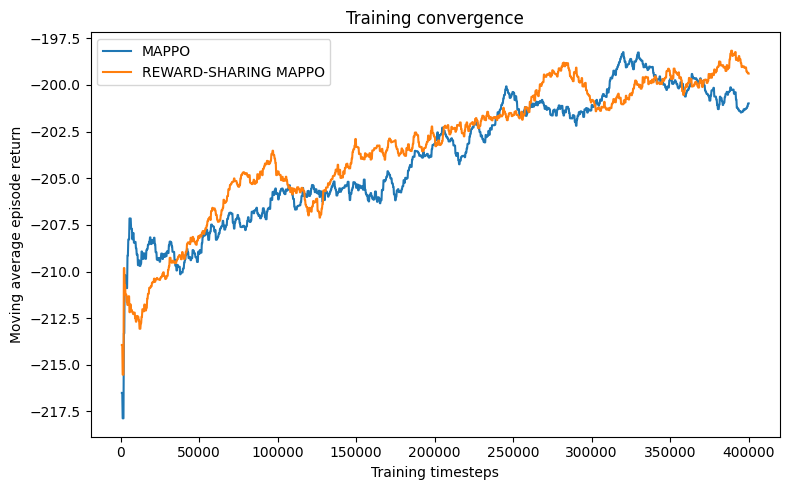

In [22]:
fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
})
plt.show()

In [23]:
from marl_tsc.evaluate_gifting import gifting_visualisation, print_gifting_summary

print_gifting_summary(reward_sharing_history, traffic_light_ids)


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.364
    Mean gift amount   : 0.1154
    Mean raw reward    : -0.3155
    Gift rate          : 0.891
Receiving and Net:    
    Mean received amount : 0.1039
    Mean net transfer    : -0.0115  (net donor)

  B2
Giving:
    Mean gift fraction : 0.365
    Mean gift amount   : 0.1246
    Mean raw reward    : -0.3398
    Gift rate          : 0.891
Receiving and Net:    
    Mean received amount : 0.0942
    Mean net transfer    : -0.0304  (net donor)

  B3
Giving:
    Mean gift fraction : 0.364
    Mean gift amount   : 0.1154
    Mean raw reward    : -0.3152
    Gift rate          : 0.891
Receiving and Net:    
    Mean received amount : 0.0977
    Mean net transfer    : -0.0177  (net donor)

  C1
Giving:
    Mean gift fraction : 0.365
    Mean gift amount   : 0.1353
    Mean raw reward    : -0.3689
    Gift rate          : 0.891
Receiving and Net:    
    Mean received amount : 0.0975
    Mean net transfer    : 

In [24]:
import importlib
import marl_tsc.evaluate_gifting as eg
importlib.reload(eg)

from marl_tsc.evaluate_gifting import (
    gifting_visualisation,
    print_gifting_summary,
    load_history_json,
    load_history_pickle,
)

Saved to /content/marl-tsc/outputs/Reward Sharing MAPPO_overview.png


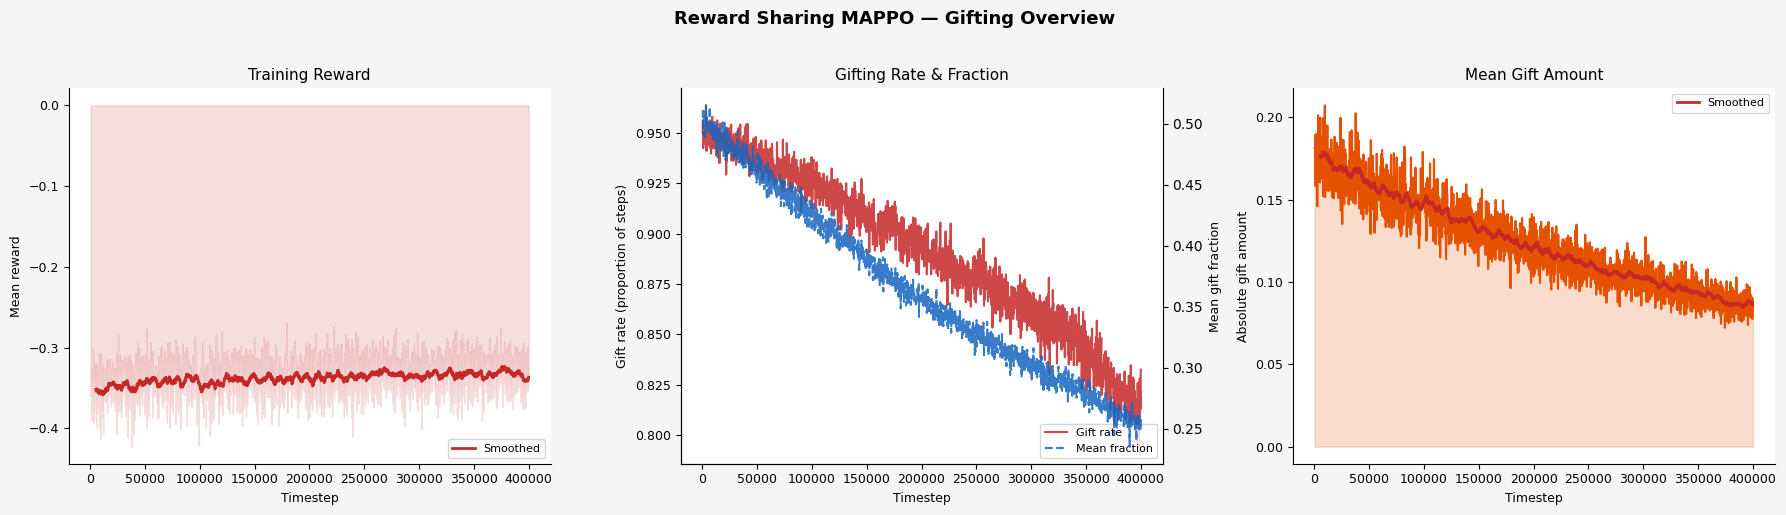

Saved to /content/marl-tsc/outputs/Reward Sharing MAPPO_per_agent.png


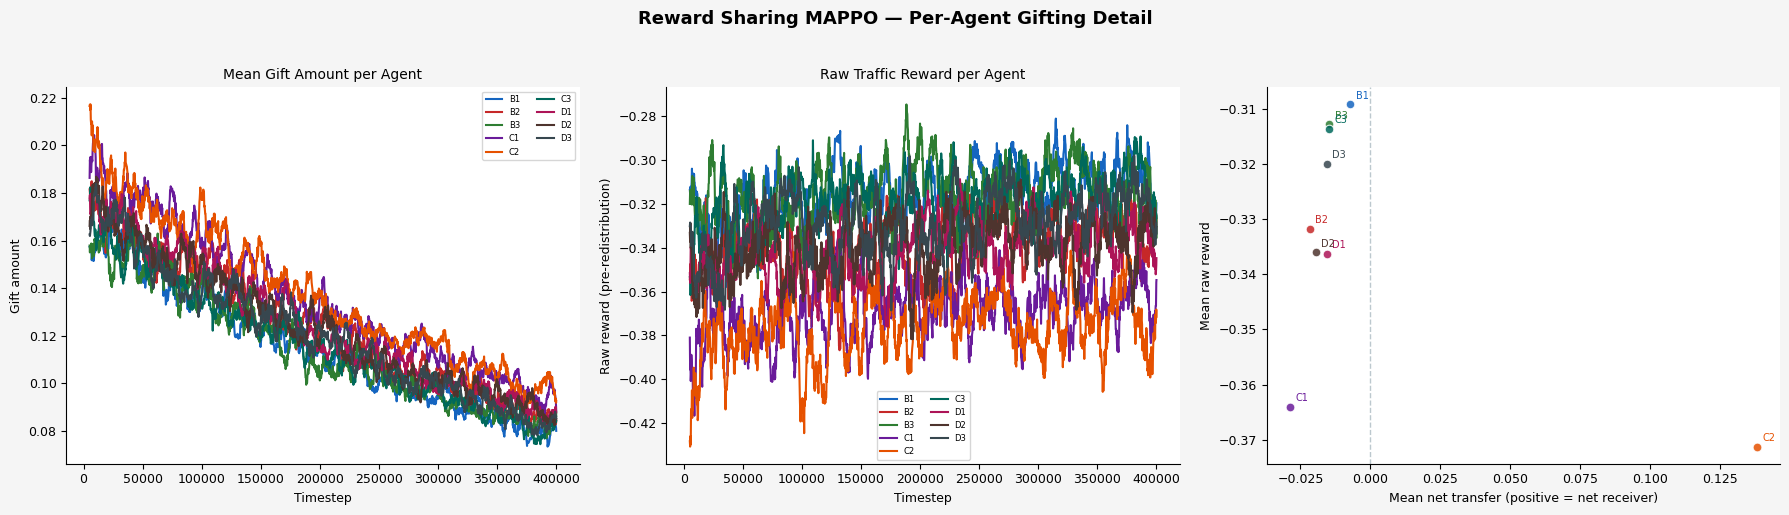

In [25]:
gifting_visualisation(
    history=reward_sharing_history,
    agent_ids=traffic_light_ids,
    algorithm_name="Reward Sharing MAPPO",
    output_dir=str(OUTPUT_DIR),
    smooth_window=20,
    save=True,
    show=True,
)

In [ ]:
'''
import pandas as pd
import matplotlib.pyplot as plt

df_mappo_history = pd.DataFrame(mappo_history)
df_mappo_history['mean_training_reward'].plot()
plt.xlabel("Timestep")
plt.ylabel("Mean Training Reward")
plt.title("MAPPO Mean Training Reward Over Timesteps")
plt.show()
'''

In [ ]:
'''
df_rs_history = pd.DataFrame(reward_sharing_history)
df_rs_history['mean_training_reward'].plot()
plt.xlabel("Timestep")
plt.ylabel("Mean Training Reward")
plt.title("Reward-sharing MAPPO Mean Training Reward Over Timesteps")
plt.show()
'''

## 3. Export a SUMO replay

In [26]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=reward_sharing_model,
    output_dir=OUTPUT_DIR / "replays" / "reward_sharing_mappo",
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)
print(f"Open this file in the SUMO GUI: {replay_config}")

 Retrying in 1 seconds
 Retrying in 1 seconds
Open this file in the SUMO GUI: /content/marl-tsc/outputs/replays/reward_sharing_mappo/replay.sumocfg


## 4. Compare all policies

Every policy uses the same evaluation episodes, seeds, and environment settings.

In [27]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
}

policy_results = evaluate_policies(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policies=policies,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)

display(evaluation_results_table(policy_results))

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1934.82
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1886.96
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -2013.68
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1303.13
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1301.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1302.48
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1044.29
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1044.84
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1019.62
Evaluating Rewar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1945.154167,0.330154,7.333333,23.967839,291.000000,3008.396454,961.333333,1616.333333
1,Fixed-Time,-1302.495833,0.224599,5.000000,16.150625,88.666667,1460.657487,973.333333,891.000000
2,MAPPO,-1036.250000,0.167253,5.333333,15.570611,298.666667,1346.425109,970.333333,1326.666667
3,Reward-sharing MAPPO,-1012.079167,0.163032,4.666667,14.823630,294.000000,1291.234690,971.000000,1312.666667


## 5. Seeded Experiments 4x4

In [28]:
EXP_SWEEP = True

|Seed: 0 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -282.70 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -289.72 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -288.90 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -293.23 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -341.34 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -281.55 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -299.87 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -286.86 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -303.06 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -292.62 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -315.28 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -275.27 | Total Steps: 7200
 R

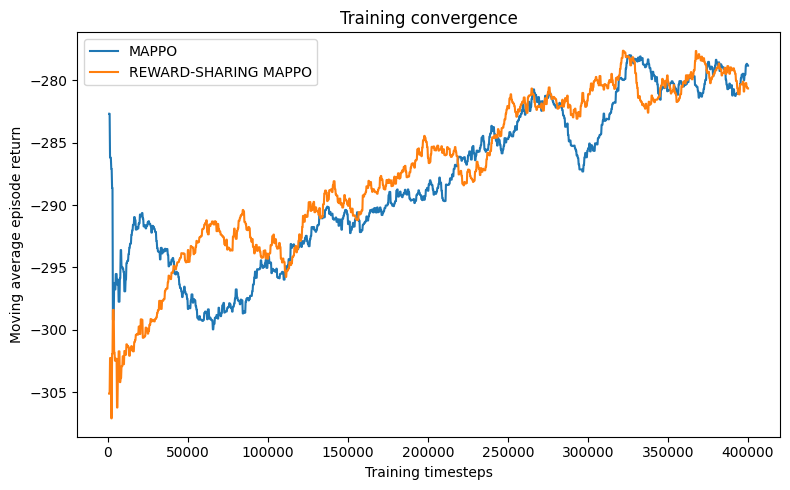

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -565.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -569.66
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -567.69
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-567.564583,0.208056,5.333333,7.961009,260.666667,558.608474,978.666667,680.333333
3,Reward-sharing MAPPO,-510.235417,0.181962,4.000000,5.676463,190.666667,466.407503,975.666667,732.666667


|Seed: 1 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -298.71 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -284.49 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -298.77 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -322.25 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -286.00 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -297.63 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -297.50 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -297.42 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -310.75 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -300.97 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -285.12 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -310.86 | Total Steps: 7200
 R

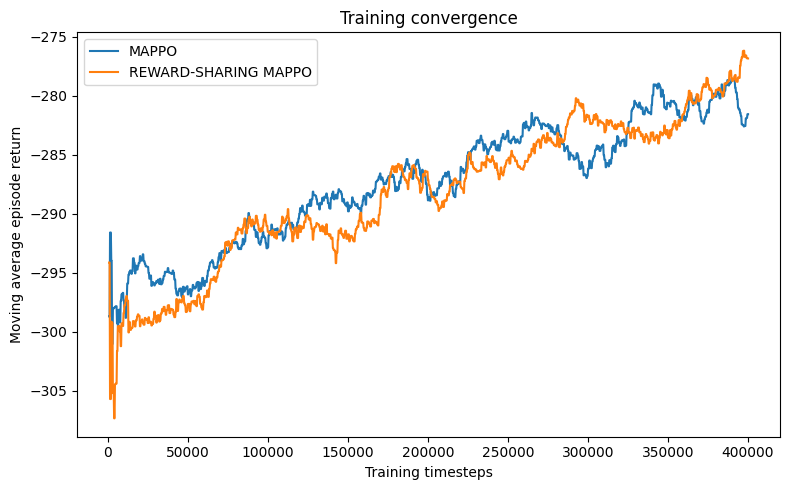

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -533.39
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -525.64
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -536.85
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-531.962500,0.191059,4.666667,6.451747,206.333333,508.211796,980.666667,732.333333
3,Reward-sharing MAPPO,-698.058333,0.262604,5.000000,11.973468,252.666667,752.832646,971.666667,674.333333


|Seed: 2 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -288.43 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -290.54 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -292.62 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -320.38 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -300.62 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -283.57 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -280.95 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -279.45 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -285.91 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -263.61 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -290.62 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -305.25 | Total Steps: 7200
 R

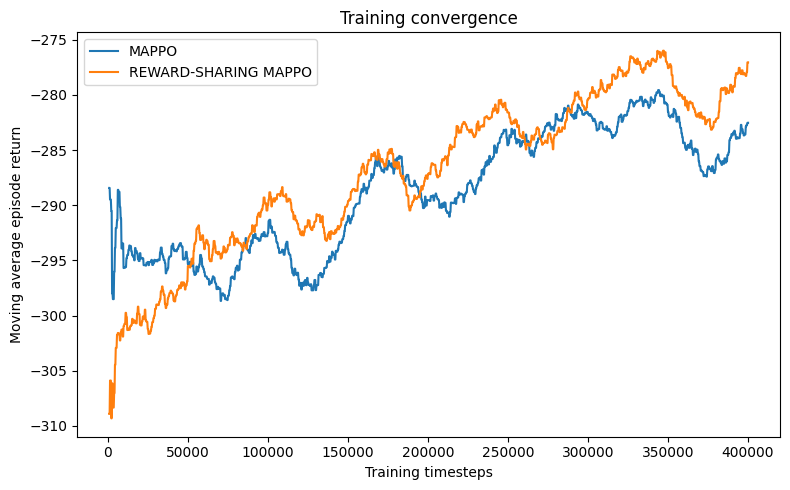

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -441.98
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -440.71
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -452.48
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-445.056250,0.153889,4.000000,3.372857,119.666667,371.545447,977.000000,755.666667
3,Reward-sharing MAPPO,-462.245833,0.160799,4.000000,3.640210,119.666667,396.408952,978.666667,761.000000


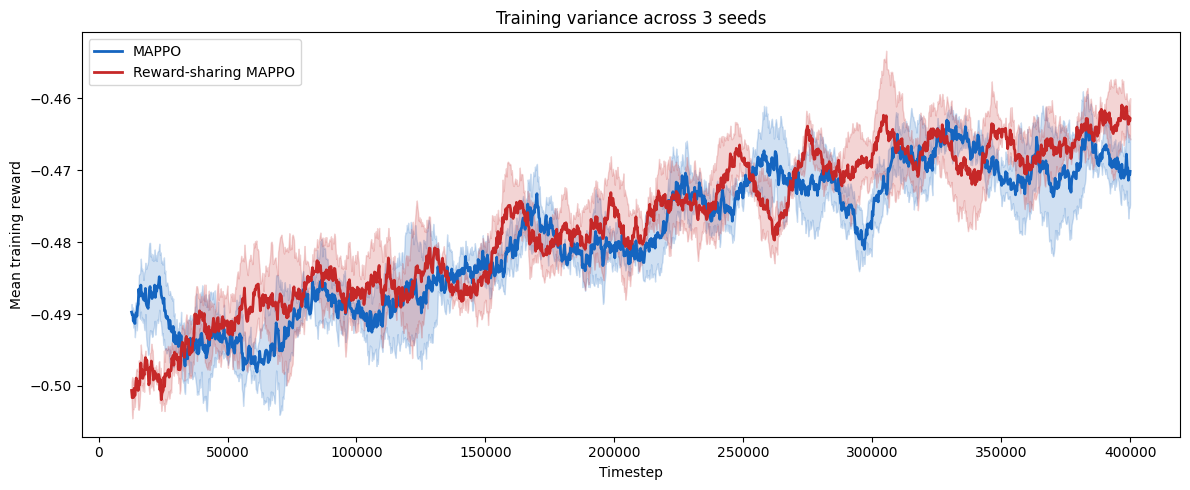

In [29]:

SEED_RANGE = 3
if EXP_SWEEP:
    from marl_tsc.exp_functions import save_history, plot_variance
    import torch

    #select network for seeded evaluation
    network = GridNetwork(4)
    generator = SimulationGenerator(
      output_dir=SIMULATION_DIR,
      network=network,
      trip_begin=0,
      trip_end=TRAFFIC_SPAWN_DURATION,
      trip_period=3,
      seed=SEED,
    )

    paths = generator.generate_all()
    traffic_light_ids = list(paths.traffic_light_ids)

    histories_mappo = []
    histories_rs   = []
    evaluation_histories = []

    #Run seeded experiment sweeps
    for seed in range(SEED_RANGE):
          torch.manual_seed(seed)
          print(f"|Seed: {seed} used for sweep|")

          #Run MAPPO
          mappo_model, mappo_history, mappo_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=False,
          )

          #Run reward sharing
          reward_sharing_model, reward_sharing_history, reward_sharing_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=True,
          )
          #Append and save
          histories_mappo.append(mappo_history)#accumulate in memory
          histories_rs.append(reward_sharing_history)
          save_history(mappo_history, seed, "mappo_4x4", OUTPUT_DIR)#save to as backup
          save_history(reward_sharing_history, seed, "rs_4x4", OUTPUT_DIR)

          #Display
          fig, ax = plot_training_histories({
          "MAPPO": mappo_history,
          "Reward-sharing MAPPO": reward_sharing_history,
          })
          plt.show()

          #Evaluate
          policies = {
          "Random": random_actions,
          "Fixed-Time": fixed_time_actions,
          "MAPPO": mappo_model,
          "Reward-sharing MAPPO": reward_sharing_model,
          }

          policy_results = evaluate_policies(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              policies=policies,
              episodes=EVALUATION_EPISODES,
              max_steps=EPISODE_STEPS,
              seed=SEED,
              env_kwargs=ENV_KWARGS,
          )
          evaluation_histories.append(policy_results)
          save_history(policy_results, seed, "eval", OUTPUT_DIR)

          display(evaluation_results_table(policy_results))

    fig, ax = plt.subplots(figsize=(12, 5))
    plot_variance(histories_mappo, "MAPPO",              "#1565C0", ax)
    plot_variance(histories_rs,   "Reward-sharing MAPPO", "#C62828", ax)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Mean training reward")
    ax.legend()
    ax.set_title(f"Training variance across {SEED_RANGE} seeds")
    plt.tight_layout()
    plt.show()

In [30]:
if EXP_SWEEP:
  import numpy as np
  metrics = ["mean_total_reward", "mean_local_queue", "mean_waiting_time",
            "mean_max_waiting_time", "mean_total_time_loss",
            "mean_arrived_vehicles_per_episode", "mean_switches_per_episode"]

  rows = []
  for policy_name in ["Random", "Fixed-Time", "MAPPO", "Reward-sharing MAPPO"]:
      row = {"Policy": policy_name}
      for metric in metrics:
          values = [e[policy_name][metric] for e in evaluation_histories]
          row[f"{metric}_mean"] = np.mean(values)
          row[f"{metric}_std"]  = np.std(values)
      rows.append(row)

  df = pd.DataFrame(rows)
  print(df.to_string())

NameError: name 'pd' is not defined

In [ ]:
if EXP_SWEEP:
  # Extract metric across seeds for each policy
  def perform_statisical_tests(metric, evaluation_histories, test_type):
    from scipy import stats
    mappo_grouping = [e["MAPPO"][metric] for e in evaluation_histories]
    rs_grouping   = [e["Reward-sharing MAPPO"][metric] for e in evaluation_histories]

    # Paired t-test — paired because same seed = same traffic conditions
    if test_type == "paired_t":
      _stat, p_value = stats.ttest_rel(mappo_grouping, rs_grouping)
      print(f"t={_stat:.5f}, p={p_value:.4f}")
    elif test_type == 'wilk':
      _stat, p_value = stats.wilcoxon(mappo_grouping, rs_grouping)
      print(f"W={_stat:.5f}, p={p_value:.4f}")
    else:
      raise ValueError(f"Unknown test type: {test_type}")

    return _stat

  perform_statisical_tests("mean_local_queue", evaluation_histories, "wilk")

In [ ]:
# Mean net transfer per agent across seeds
for agent_id in traffic_light_ids:
    net_transfers = [
        np.mean([h["per_agent_gifting"][agent_id]["mean_net_transfer"]
                 for h in history if "per_agent_gifting" in h])
        for history in histories_rs
    ]
    print(f"{agent_id}: {np.mean(net_transfers):.4f} ± {np.std(net_transfers):.4f}")

In [ ]:
for seed, history in enumerate(histories_rs):
    print(f"\n{'='*50}\nSeed {seed}\n{'='*50}")
    gifting_visualisation(
        history=history,
        agent_ids=traffic_light_ids,
        algorithm_name=f"Reward-sharing MAPPO — Seed {seed}",
        output_dir=str(OUTPUT_DIR),
        show=False,   # don't display inline for every seed
        save=True,    # just save to Drive
    )
    print_gifting_summary(history, traffic_light_ids)

In [14]:
!git status
#!git add .
commit = False
if commit:
  import shlex
  commit_msg = '''
  Updated to reflect gifts recieved as well as given
  '''
  !git config --global user.email user_email
  !git config --global user.name 'IsaacFayle-Waters'
  !git commit -m {shlex.quote(commit_msg)}

On branch zak-pre-experiment
Your branch is ahead of 'origin/zak-pre-experiment' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [16]:
#!git pull --rebase origin zak-pre-experiment

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 721.28 KiB | 1.70 MiB/s, done.
From https://github.com/abergh18/marl-tsc
 * branch            zak-pre-experiment -> FETCH_HEAD
   62a616d..e107429  zak-pre-experiment -> origin/zak-pre-experiment
Successfully rebased and updated refs/heads/zak-pre-experiment.


In [17]:
#!git remote set-url origin https://{token}@github.com/abergh18/marl-tsc.git
#!git push -u origin zak-pre-experiment

Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (7/7), 1.22 KiB | 1.22 MiB/s, done.
Total 7 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/abergh18/marl-tsc.git
   e107429..1829ab2  zak-pre-experiment -> zak-pre-experiment
Branch 'zak-pre-experiment' set up to track remote branch 'zak-pre-experiment' from 'origin'.
